# Flickr8k — EDA + Preprocessing

This notebook produces the artifacts the rest of the pipeline depends on:

- `data/processed/vocab.pkl` — `Vocabulary` built from the **train split only**
- `data/processed/{train,val,test}_data.pkl` — pre-numericalized splits (image-level, no leakage)
- EDA plots used in the final report (caption length, word frequency, vocab-vs-threshold curve)

Run end-to-end with Kernel → Restart & Run All.


In [1]:
import os
import pickle
import random
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

from src.vocabulary import Vocabulary

sns.set_theme(style='whitegrid')
random.seed(42)
np.random.seed(42)

RAW_DIR = os.path.join(REPO_ROOT, 'data', 'raw')
IMAGES_DIR = os.path.join(RAW_DIR, 'Images')
CAPTIONS_PATH = os.path.join(RAW_DIR, 'captions.txt')
PROCESSED_DIR = os.path.join(REPO_ROOT, 'data', 'processed')
os.makedirs(PROCESSED_DIR, exist_ok=True)

print('repo:', REPO_ROOT)
print('images dir exists:', os.path.isdir(IMAGES_DIR))
print('captions file exists:', os.path.isfile(CAPTIONS_PATH))

repo: /home/omargamalelkady/ITI/Courses/Deep-Learning/Project/flickr8k-image-captioning
images dir exists: True
captions file exists: True


## 1. Load captions

In [2]:
df = pd.read_csv(CAPTIONS_PATH)
print('shape:', df.shape)
print('columns:', list(df.columns))
print('unique images:', df['image'].nunique())
print('captions per image (sample):')
print(df.groupby('image').size().describe())
df.head()

shape: (40455, 2)
columns: ['image', 'caption']
unique images: 8091
captions per image (sample):
count    8091.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [3]:
# Confirm every image has exactly 5 captions
per_image = df.groupby('image').size()
assert (per_image == 5).all(), f'Not all images have 5 captions: {per_image.value_counts().to_dict()}'
print('All 8091 images have 5 captions each.')

All 8091 images have 5 captions each.


## 2. Caption length distribution

We tokenize exactly the way `Vocabulary.tokenize` does (lowercase → punctuation strip) so the statistics match the training pipeline.

length stats:
count    40455.000000
mean        10.816982
std          3.769411
min          1.000000
50%         10.000000
90%         16.000000
95%         18.000000
99%         22.000000
max         37.000000
Name: length, dtype: float64


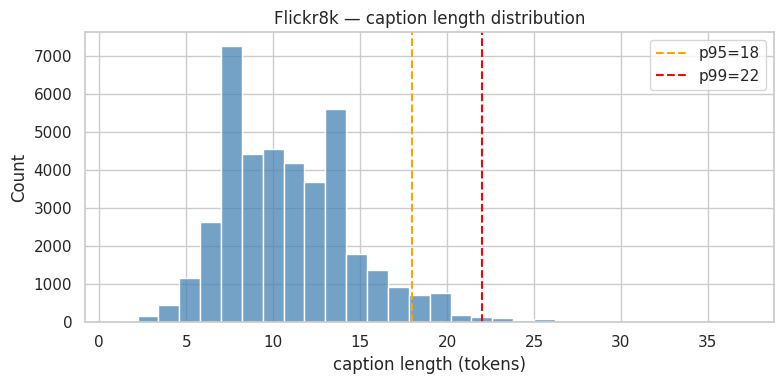

In [4]:
df['tokens'] = df['caption'].map(Vocabulary.tokenize)
df['length'] = df['tokens'].map(len)

print('length stats:')
print(df['length'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['length'], bins=30, ax=ax, color='steelblue')
for q, color in [(0.95, 'orange'), (0.99, 'red')]:
    v = df['length'].quantile(q)
    ax.axvline(v, color=color, linestyle='--', label=f'p{int(q*100)}={v:.0f}')
ax.set_xlabel('caption length (tokens)')
ax.set_title('Flickr8k — caption length distribution')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Word frequency

Computed on the **whole dataset** for EDA; the actual training vocabulary uses train-only counts.

raw vocabulary size (freq>=1): 8488
tokens total: 437601


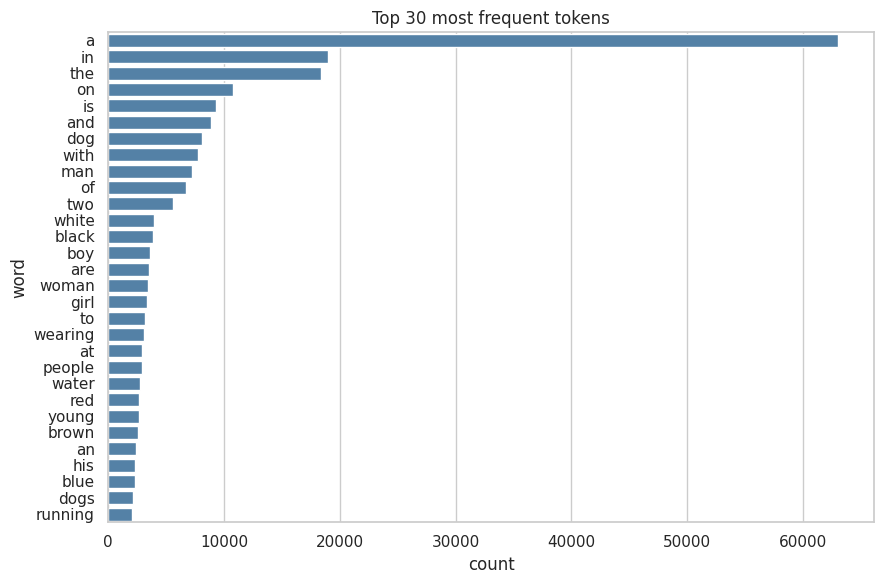

In [5]:
counter_all = Counter()
for toks in df['tokens']:
    counter_all.update(toks)

print('raw vocabulary size (freq>=1):', len(counter_all))
print('tokens total:', sum(counter_all.values()))

top_n = 30
top_words = counter_all.most_common(top_n)
top_df = pd.DataFrame(top_words, columns=['word', 'count'])

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_df, y='word', x='count', ax=ax, color='steelblue')
ax.set_title(f'Top {top_n} most frequent tokens')
plt.tight_layout()
plt.show()

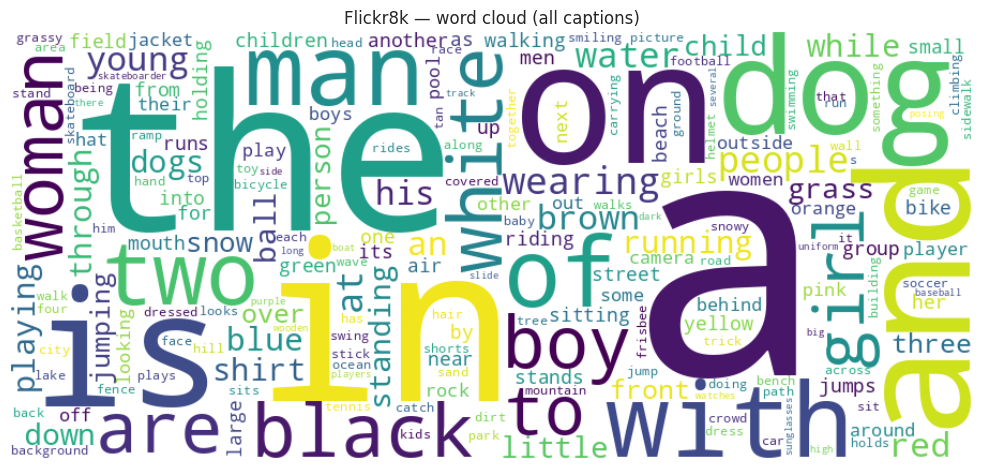

In [6]:
# Word cloud (sanity check for top content words)
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=900, height=400, background_color='white').generate_from_frequencies(counter_all)
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title('Flickr8k — word cloud (all captions)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('wordcloud skipped:', e)

## 4. Vocabulary size vs frequency threshold

Picks the threshold that keeps the decoder softmax small without dropping too much semantic content.

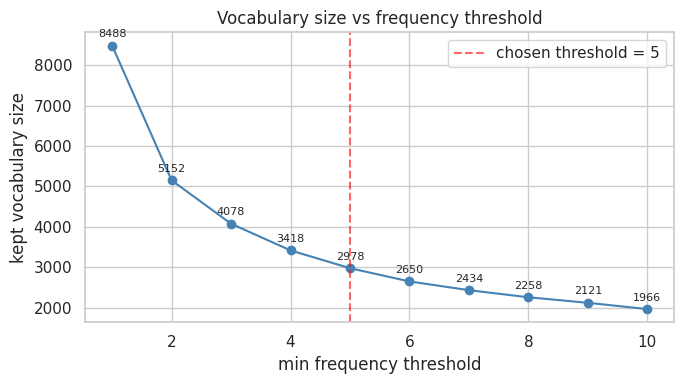

In [7]:
thresholds = list(range(1, 11))
sizes = [sum(1 for _, c in counter_all.items() if c >= t) for t in thresholds]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, sizes, marker='o', color='steelblue')
for t, s in zip(thresholds, sizes):
    ax.annotate(f'{s}', (t, s), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=8)
ax.axvline(5, color='red', linestyle='--', alpha=0.6, label='chosen threshold = 5')
ax.set_xlabel('min frequency threshold')
ax.set_ylabel('kept vocabulary size')
ax.set_title('Vocabulary size vs frequency threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Sample image-caption pairs

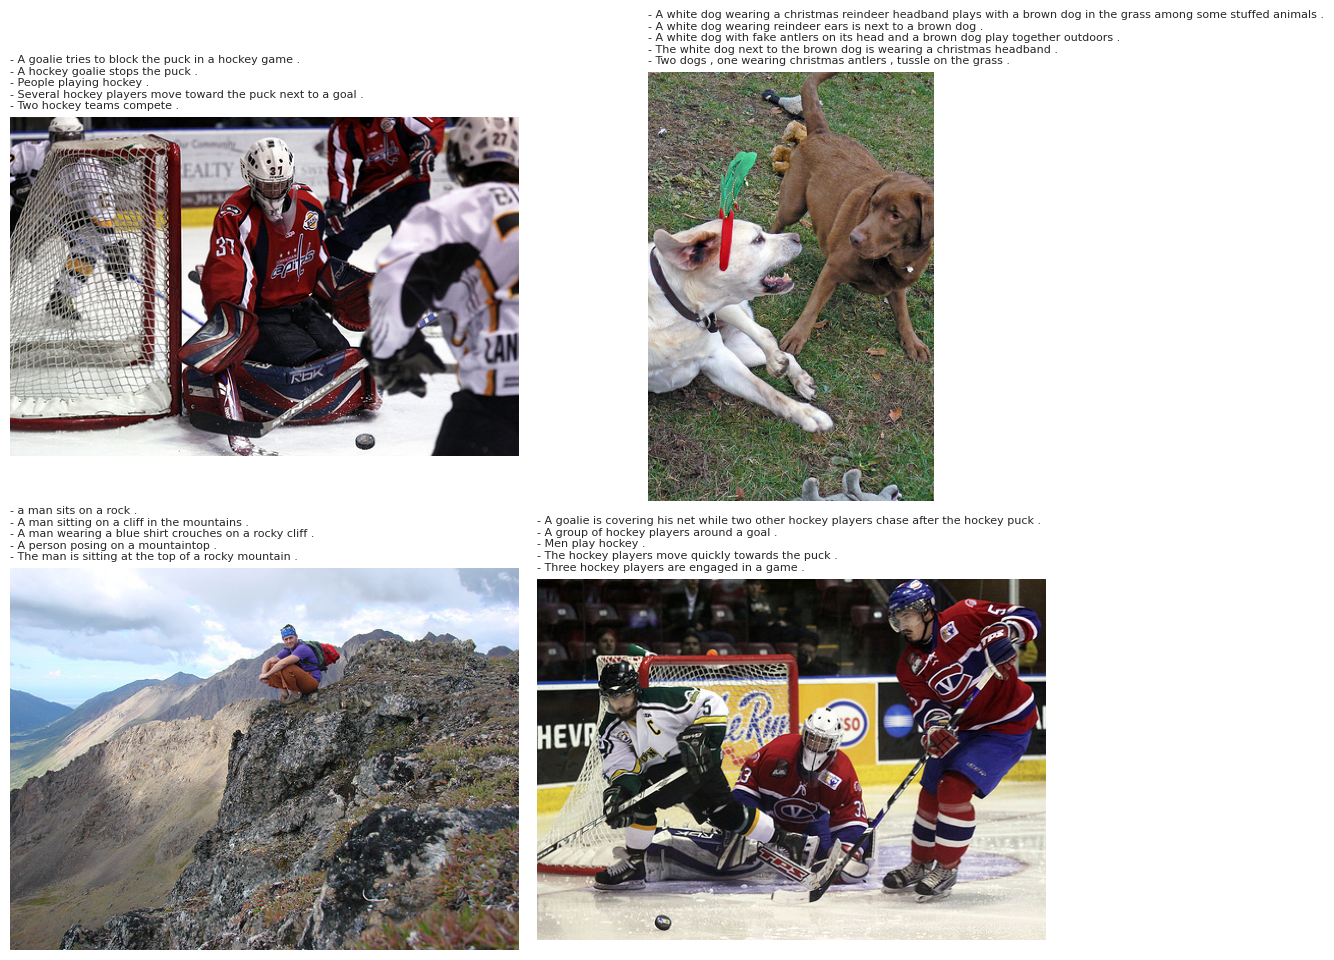

In [8]:
sample_imgs = random.sample(sorted(df['image'].unique()), 4)
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
for ax, img_id in zip(axes.flat, sample_imgs):
    with Image.open(os.path.join(IMAGES_DIR, img_id)) as img:
        ax.imshow(img)
    caps = df.loc[df['image'] == img_id, 'caption'].tolist()
    ax.set_title('\n'.join(f'- {c}' for c in caps), fontsize=8, loc='left')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Image-level split (6000 / 1000 / 1091)

**Critical:** we split on unique image IDs, then flatten to (image, caption) rows. This prevents the same image's captions from ending up in both train and test — the #1 silent bug in captioning projects.

In [9]:
all_image_ids = sorted(df['image'].unique())
rng = np.random.default_rng(42)
shuffled = np.array(all_image_ids)
rng.shuffle(shuffled)

n_train, n_val = 6000, 1000
train_ids = shuffled[:n_train].tolist()
val_ids = shuffled[n_train:n_train + n_val].tolist()
test_ids = shuffled[n_train + n_val:].tolist()

print('train:', len(train_ids))
print('val:  ', len(val_ids))
print('test: ', len(test_ids))
assert len(train_ids) + len(val_ids) + len(test_ids) == len(all_image_ids)
assert set(train_ids).isdisjoint(val_ids)
assert set(train_ids).isdisjoint(test_ids)
assert set(val_ids).isdisjoint(test_ids)
print('no image leakage between splits.')

train: 6000
val:   1000
test:  1091
no image leakage between splits.


## 7. Build vocabulary from TRAIN captions only

In [10]:
captions_by_image = df.groupby('image')['caption'].apply(list).to_dict()

train_captions = [c for img in train_ids for c in captions_by_image[img]]
val_captions = [c for img in val_ids for c in captions_by_image[img]]
test_captions = [c for img in test_ids for c in captions_by_image[img]]

print(f'train captions: {len(train_captions)}')
print(f'val captions:   {len(val_captions)}')
print(f'test captions:  {len(test_captions)}')

vocab = Vocabulary(freq_threshold=5)
vocab.build_from_captions(train_captions)
print(f'\nvocabulary size (incl. 4 specials): {len(vocab)}')

# Coverage: what % of val/test tokens are in-vocabulary?
val_cov = vocab.coverage(val_captions)
test_cov = vocab.coverage(test_captions)
print(f'val token coverage:  {val_cov*100:.2f}%')
print(f'test token coverage: {test_cov*100:.2f}%')

# Round-trip sanity
sample = train_captions[0]
ids = vocab.numericalize(sample)
print(f'\nsample: {sample!r}')
print(f'ids:    {ids[:15]}...')
print(f'decode: {vocab.denumericalize(ids)!r}')

train captions: 30000
val captions:   5000
test captions:  5455

vocabulary size (incl. 4 specials): 2557


val token coverage:  96.94%
test token coverage: 96.97%

sample: 'A female lionist jumping in a green field with a green mountain in the background .'
ids:    [1, 11, 770, 3, 1159, 1100, 11, 941, 781, 2521, 11, 941, 1371, 1100, 2276]...
decode: 'a female jumping in a green field with a green mountain in the background'


## 8. Pickle artifacts


In [11]:
def numericalize_split(image_ids):
    return {
        'image_ids': list(image_ids),
        'captions': {
            img: [vocab.numericalize(c) for c in captions_by_image[img]]
            for img in image_ids
        },
        'captions_text': {img: list(captions_by_image[img]) for img in image_ids},
    }

train_data = numericalize_split(train_ids)
val_data = numericalize_split(val_ids)
test_data = numericalize_split(test_ids)

with open(os.path.join(PROCESSED_DIR, 'vocab.pkl'), 'wb') as f:
    pickle.dump(vocab, f)
with open(os.path.join(PROCESSED_DIR, 'train_data.pkl'), 'wb') as f:
    pickle.dump(train_data, f)
with open(os.path.join(PROCESSED_DIR, 'val_data.pkl'), 'wb') as f:
    pickle.dump(val_data, f)
with open(os.path.join(PROCESSED_DIR, 'test_data.pkl'), 'wb') as f:
    pickle.dump(test_data, f)

for name in ['vocab.pkl', 'train_data.pkl', 'val_data.pkl', 'test_data.pkl']:
    path = os.path.join(PROCESSED_DIR, name)
    print(f'{name:18s} {os.path.getsize(path)/1024:8.1f} KiB')

vocab.pkl             123.1 KiB
train_data.pkl       3064.9 KiB
val_data.pkl          509.1 KiB
test_data.pkl         556.2 KiB


## 9. Smoke test — load a real batch through `FlickrDataset` + `collate_fn`

In [12]:
import torch
from torch.utils.data import DataLoader
from src.dataset import FlickrDataset, build_eval_transform, build_items, build_train_transform, collate_fn

train_items = build_items(train_ids, captions_by_image, vocab)
print(f'train rows (image x 5 captions): {len(train_items)}')

train_ds = FlickrDataset(train_items, IMAGES_DIR, build_train_transform())
loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn, num_workers=0)

images, captions, lengths = next(iter(loader))
print('images:  ', tuple(images.shape), images.dtype)
print('captions:', tuple(captions.shape), captions.dtype)
print('lengths: ', tuple(lengths.shape), lengths.dtype)
assert images.shape == (32, 3, 224, 224)
assert captions.dtype == torch.long
assert (lengths > 0).all()
assert int(captions.max()) < len(vocab)
print('\nsample decoded caption:', vocab.denumericalize(captions[0].tolist()))

train rows (image x 5 captions): 30000
images:   (32, 3, 224, 224) torch.float32
captions: (32, 23) torch.int64
lengths:  (32,) torch.int64

sample decoded caption: a brown and white dog is playing in a pool with a man


## 10. Visual sanity check — 4 augmented training crops

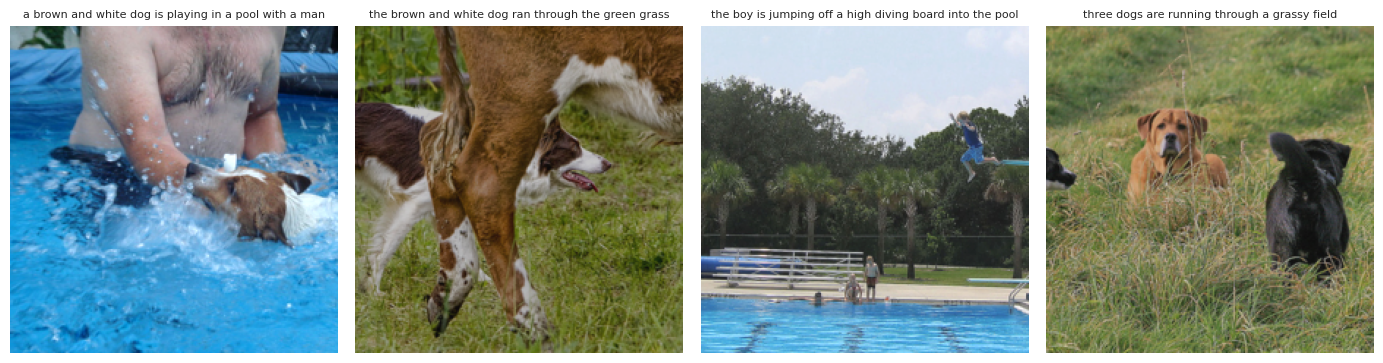

In [13]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, ax in enumerate(axes):
    img = (images[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(vocab.denumericalize(captions[i].tolist())[:60], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()